# Analyse des anomalies boursières — Pipeline ETL Fortuneo

Ce notebook présente une analyse visuelle des résultats produits par le pipeline ETL de surveillance du risque boursier.
Il charge les données transformées et les anomalies détectées par le modèle Isolation Forest, puis génère des visualisations interprétables par les équipes métiers du Data Lab.

> **Contexte** : les données proviennent de l'API publique Yahoo Finance et concernent 12 actions du CAC40 sur une période d'un an.

## 1. Importation des bibliothèques

In [1]:
# Importation des bibliothèques de manipulation de données
import pandas as pd
import numpy as np
import os
import glob
from pathlib import Path

# Importation des bibliothèques de visualisation
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Configuration du style des graphiques pour un rendu professionnel
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Paramètres globaux d'affichage des graphiques
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

# Désactivation des avertissements pandas pour un affichage plus propre
import warnings
warnings.filterwarnings('ignore')

print('Bibliothèques chargées avec succès.')

Bibliothèques chargées avec succès.


## 2. Chargement des données produites par le pipeline

In [2]:
# Définition du chemin racine du projet de façon robuste
# os.getcwd() retourne le dossier courant d'exécution du notebook (notebooks/)
# On remonte d'un niveau pour atteindre la racine du projet
RACINE = Path(os.getcwd()).parent

print(f'Racine du projet détectée : {RACINE}')

# Dossier contenant les fichiers Parquet des données transformées (une par symbole)
DOSSIER_TRANSFORME = RACINE / 'data' / 'transformees' / 'donnees_transformees'

# Dossier contenant les fichiers Parquet des anomalies détectées
DOSSIER_ANOMALIES = RACINE / 'data' / 'transformees' / 'anomalies_detectees'

print(f'Fichiers trouvés (transformées) : {len(list(DOSSIER_TRANSFORME.glob("*.parquet")))}')
print(f'Fichiers trouvés (anomalies)    : {len(list(DOSSIER_ANOMALIES.glob("*.parquet")))}')

# Chargement de tous les fichiers Parquet des données transformées en un seul DataFrame
fichiers_transformes = list(DOSSIER_TRANSFORME.glob('*.parquet'))
df = pd.concat([pd.read_parquet(f) for f in fichiers_transformes], ignore_index=True)

# Chargement de tous les fichiers Parquet des anomalies détectées
fichiers_anomalies = list(DOSSIER_ANOMALIES.glob('*.parquet'))
df_anomalies = pd.concat([pd.read_parquet(f) for f in fichiers_anomalies], ignore_index=True)

# Conversion de la colonne date en type datetime pour les graphiques temporels
df['date'] = pd.to_datetime(df['date'])
df_anomalies['date'] = pd.to_datetime(df_anomalies['date'])

# Tri chronologique des données pour les visualisations
df = df.sort_values(['symbole', 'date']).reset_index(drop=True)
df_anomalies = df_anomalies.sort_values(['symbole', 'date']).reset_index(drop=True)

print(f'\nDonnées transformées : {len(df):,} lignes | {df["symbole"].nunique()} symboles')
print(f'Données anomalies    : {len(df_anomalies):,} lignes')
print(f'Période              : {df["date"].min().date()} → {df["date"].max().date()}')
print(f'Symboles             : {sorted(df["symbole"].unique())}')

Racine du projet détectée : c:\Users\agatw\Downloads\Fortuneo\Projet_ETL_
Fichiers trouvés (transformées) : 11
Fichiers trouvés (anomalies)    : 11

Données transformées : 2,662 lignes | 11 symboles
Données anomalies    : 2,662 lignes
Période              : 2025-04-23 → 2026-04-01
Symboles             : ['AIR.PA', 'BNP.PA', 'CS.PA', 'DG.PA', 'DSY.PA', 'EL.PA', 'KER.PA', 'MC.PA', 'OR.PA', 'SAN.PA', 'TTE.PA']


## 3. Aperçu des données

In [3]:
# Affichage des premières lignes du DataFrame avec les colonnes clés
df_anomalies[['date','symbole','cloture','rendement_log','volatilite_annualisee','rsi','score_anomalie','est_anomalie','label_anomalie']].head()

,date,symbole,cloture,rendement_log,volatilite_annualisee,rsi,score_anomalie,est_anomalie,label_anomalie
0,2025-04-23,AIR.PA,138.839996,0.042522,0.626080,38.681411,-0.556765,False,Normal
1,2025-04-24,AIR.PA,137.259995,-0.011445,0.603311,37.074005,-0.490333,False,Normal
2,2025-04-25,AIR.PA,140.600006,0.024042,0.600162,42.512421,-0.498478,False,Normal
3,2025-04-28,AIR.PA,144.320007,0.026114,0.597294,47.911998,-0.500256,False,Normal
4,2025-04-29,AIR.PA,143.979996,-0.002359,0.579798,47.473095,-0.476051,False,Normal


In [4]:
# Statistiques descriptives sur les principales métriques de risque
colonnes_risque = ['cloture', 'rendement_log', 'volatilite_annualisee', 'rsi', 'var_historique_99', 'score_anomalie']
df_anomalies[colonnes_risque].describe().round(4)

,cloture,rendement_log,volatilite_annualisee,rsi,var_historique_99,score_anomalie
count,2662.0000,2662.0000,2662.0000,2662.0000,2662.0000,2662.0000
mean,182.3196,0.0003,0.2747,50.9789,-0.0390,-0.4530
std,154.3188,0.0176,0.1122,12.7330,0.0247,0.0536
min,15.9600,-0.2333,0.1050,16.8470,-0.1976,-0.7537
25%,55.3956,-0.0079,0.1928,41.4265,-0.0470,-0.4720
50%,121.8546,0.0006,0.2503,50.9408,-0.0320,-0.4404
75%,270.2000,0.0092,0.3230,60.3886,-0.0227,-0.4159
max,652.1000,0.1220,0.8177,86.8770,-0.0095,-0.3775


## 4. Résumé des anomalies détectées par symbole

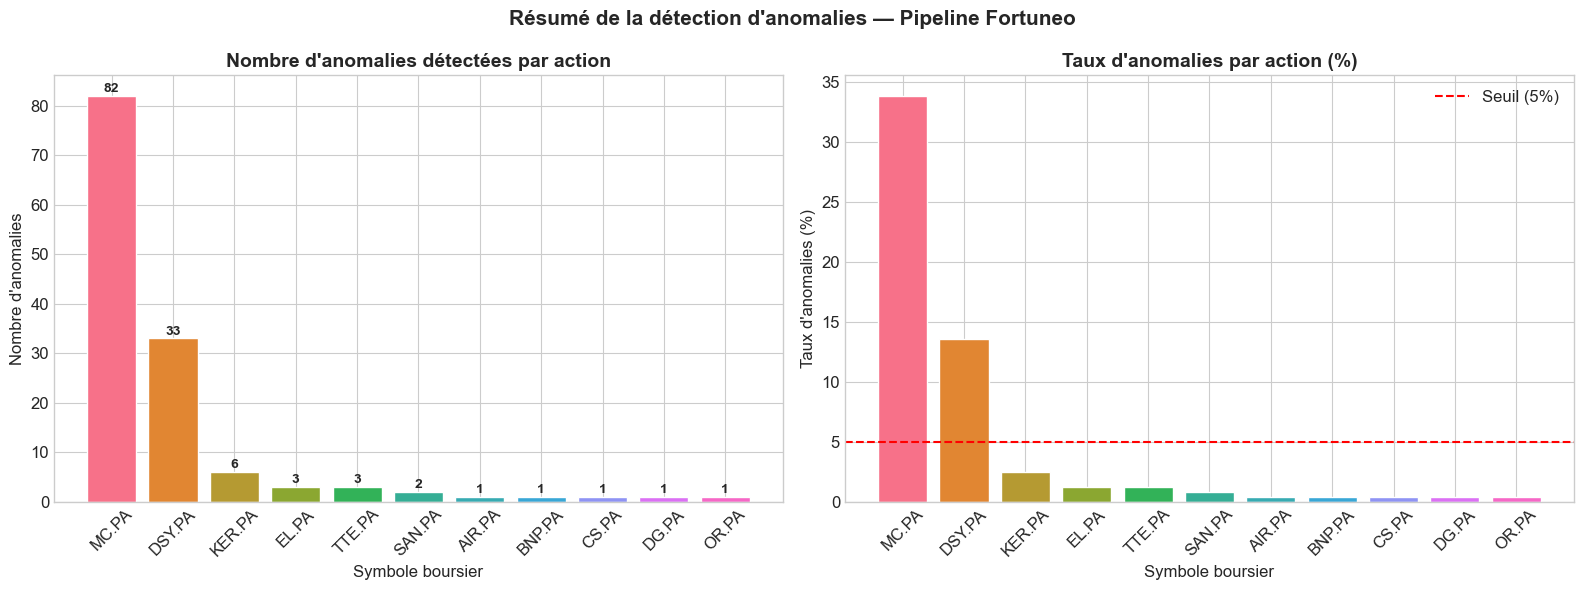

,symbole,nb_observations,nb_anomalies,taux_pct,score_moyen
7,MC.PA,242,82,33.9,-0.543
4,DSY.PA,242,33,13.6,-0.483
6,KER.PA,242,6,2.5,-0.471
5,EL.PA,242,3,1.2,-0.457
10,TTE.PA,242,3,1.2,-0.430
9,SAN.PA,242,2,0.8,-0.418
0,AIR.PA,242,1,0.4,-0.435
1,BNP.PA,242,1,0.4,-0.425
2,CS.PA,242,1,0.4,-0.436
3,DG.PA,242,1,0.4,-0.422


In [5]:
# Calcul du nombre et du taux d'anomalies par symbole boursier
resume_anomalies = (
    df_anomalies.groupby('symbole')
    .agg(
        nb_observations=('est_anomalie', 'count'),
        nb_anomalies=('est_anomalie', 'sum'),
        taux_anomalies=('est_anomalie', 'mean'),
        score_moyen=('score_anomalie', 'mean'),
        score_min=('score_anomalie', 'min'),
    )
    .reset_index()
    .sort_values('taux_anomalies', ascending=False)
)
resume_anomalies['taux_pct'] = (resume_anomalies['taux_anomalies'] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graphique gauche : nombre absolu d'anomalies par symbole
barres = axes[0].bar(
    resume_anomalies['symbole'], resume_anomalies['nb_anomalies'],
    color=sns.color_palette('husl', len(resume_anomalies)), edgecolor='white'
)
for barre in barres:
    axes[0].text(barre.get_x() + barre.get_width()/2., barre.get_height() + 0.1,
                 f'{int(barre.get_height())}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title("Nombre d'anomalies détectées par action")
axes[0].set_xlabel('Symbole boursier')
axes[0].set_ylabel("Nombre d'anomalies")
axes[0].tick_params(axis='x', rotation=45)

# Graphique droite : taux d'anomalies en pourcentage
axes[1].bar(
    resume_anomalies['symbole'], resume_anomalies['taux_pct'],
    color=sns.color_palette('husl', len(resume_anomalies)), edgecolor='white'
)
# Ligne de référence : taux de contamination configuré (5%)
axes[1].axhline(y=5, color='red', linestyle='--', linewidth=1.5, label='Seuil (5%)')
axes[1].set_title("Taux d'anomalies par action (%)")
axes[1].set_xlabel('Symbole boursier')
axes[1].set_ylabel("Taux d'anomalies (%)")
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.suptitle("Résumé de la détection d'anomalies — Pipeline Fortuneo", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('anomalies_par_symbole.png', dpi=150, bbox_inches='tight')
plt.show()

resume_anomalies[['symbole', 'nb_observations', 'nb_anomalies', 'taux_pct', 'score_moyen']].round(3)

## 5. Évolution du prix et détection d'anomalies

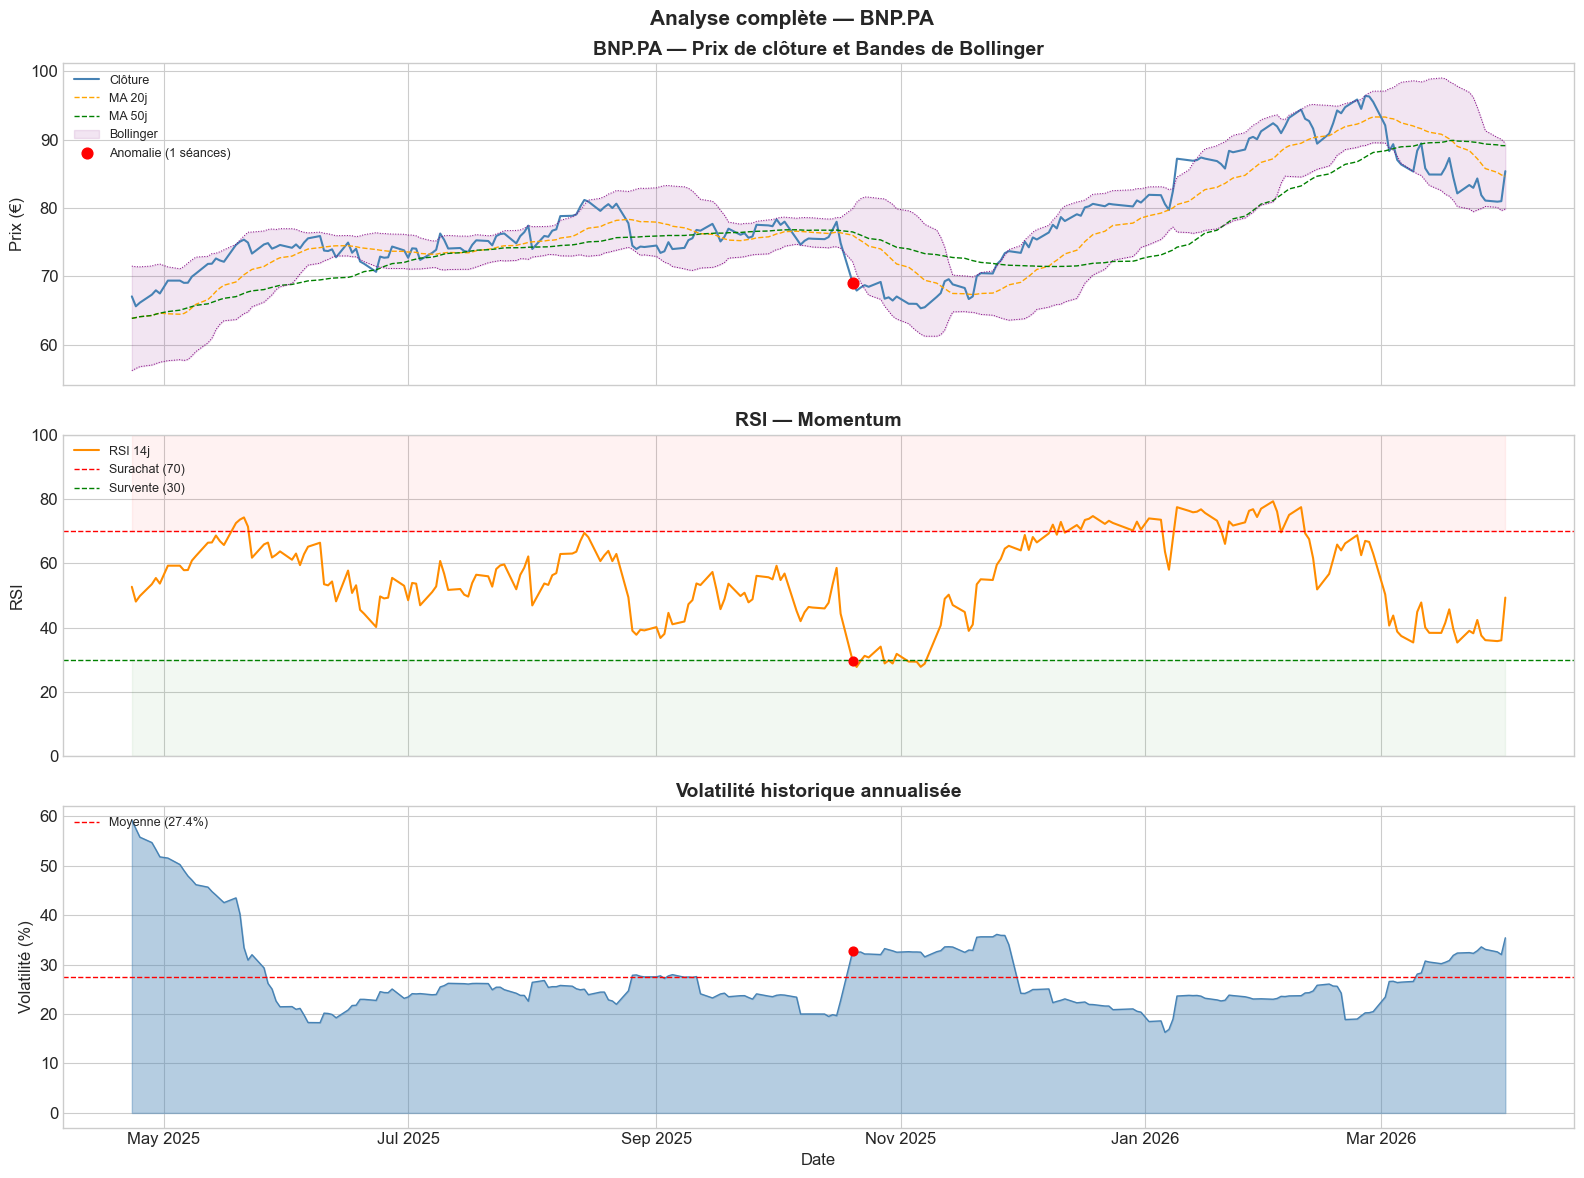

In [6]:
def tracer_prix_anomalies(symbole, df_source):
    """
    Trace le cours d'une action avec les Bandes de Bollinger
    et met en évidence les séances anormales détectées par le modèle ML.
    """
    df_sym = df_source[df_source['symbole'] == symbole].copy()
    if df_sym.empty:
        print(f'Aucune donnée pour {symbole}')
        return

    anomalies = df_sym[df_sym['est_anomalie'] == True]

    fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

    # --- Graphique 1 : Prix + Bandes de Bollinger ---
    axes[0].plot(df_sym['date'], df_sym['cloture'], color='steelblue', linewidth=1.5, label='Clôture')
    axes[0].plot(df_sym['date'], df_sym['ma_courte'], color='orange', linewidth=1, linestyle='--', label='MA 20j')
    axes[0].plot(df_sym['date'], df_sym['ma_longue'], color='green', linewidth=1, linestyle='--', label='MA 50j')
    axes[0].fill_between(df_sym['date'], df_sym['bollinger_haute'], df_sym['bollinger_basse'],
                         alpha=0.1, color='purple', label='Bollinger')
    axes[0].plot(df_sym['date'], df_sym['bollinger_haute'], color='purple', linewidth=0.7, linestyle=':')
    axes[0].plot(df_sym['date'], df_sym['bollinger_basse'], color='purple', linewidth=0.7, linestyle=':')
    axes[0].scatter(anomalies['date'], anomalies['cloture'], color='red', s=60, zorder=5,
                    label=f'Anomalie ({len(anomalies)} séances)')
    axes[0].set_title(f'{symbole} — Prix de clôture et Bandes de Bollinger')
    axes[0].set_ylabel('Prix (€)')
    axes[0].legend(loc='upper left', fontsize=9)

    # --- Graphique 2 : RSI ---
    axes[1].plot(df_sym['date'], df_sym['rsi'], color='darkorange', linewidth=1.5, label='RSI 14j')
    axes[1].axhline(y=70, color='red', linestyle='--', linewidth=1, label='Surachat (70)')
    axes[1].axhline(y=30, color='green', linestyle='--', linewidth=1, label='Survente (30)')
    axes[1].fill_between(df_sym['date'], 70, 100, alpha=0.05, color='red')
    axes[1].fill_between(df_sym['date'], 0, 30, alpha=0.05, color='green')
    axes[1].scatter(anomalies['date'], anomalies['rsi'], color='red', s=40, zorder=5)
    axes[1].set_title('RSI — Momentum')
    axes[1].set_ylabel('RSI')
    axes[1].set_ylim(0, 100)
    axes[1].legend(loc='upper left', fontsize=9)

    # --- Graphique 3 : Volatilité ---
    axes[2].fill_between(df_sym['date'], df_sym['volatilite_annualisee'] * 100, alpha=0.4, color='steelblue')
    axes[2].plot(df_sym['date'], df_sym['volatilite_annualisee'] * 100, color='steelblue', linewidth=1)
    vol_moy = df_sym['volatilite_annualisee'].mean() * 100
    axes[2].axhline(y=vol_moy, color='red', linestyle='--', linewidth=1, label=f'Moyenne ({vol_moy:.1f}%)')
    axes[2].scatter(anomalies['date'], anomalies['volatilite_annualisee'] * 100, color='red', s=40, zorder=5)
    axes[2].set_title('Volatilité historique annualisée')
    axes[2].set_ylabel('Volatilité (%)')
    axes[2].set_xlabel('Date')
    axes[2].legend(loc='upper left', fontsize=9)
    axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=2))

    plt.suptitle(f'Analyse complète — {symbole}', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'analyse_{symbole.replace(".", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

# Application sur BNP Paribas — modifie le symbole pour explorer d'autres actions
tracer_prix_anomalies('BNP.PA', df_anomalies)

## 6. Comparaison de la volatilité entre tous les symboles

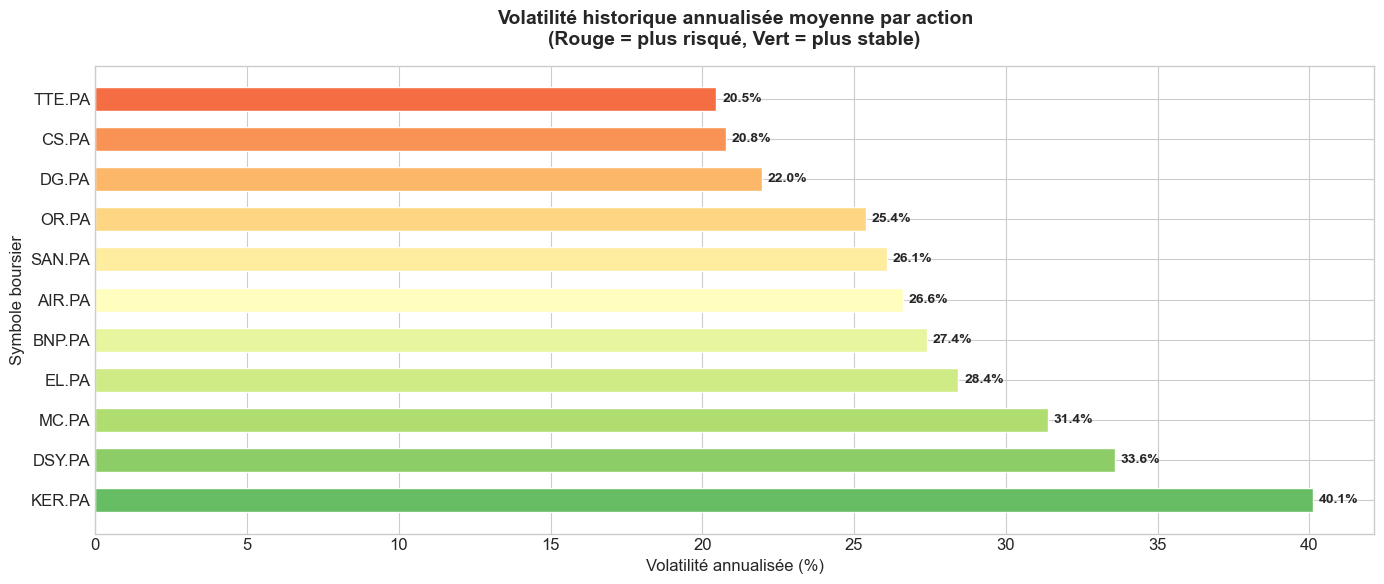

In [7]:
# Volatilité moyenne annualisée par symbole, triée du plus risqué au plus stable
vol_par_symbole = (
    df_anomalies.groupby('symbole')['volatilite_annualisee'].mean().sort_values(ascending=False) * 100
)

fig, ax = plt.subplots(figsize=(14, 6))
couleurs = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(vol_par_symbole)))
barres = ax.barh(vol_par_symbole.index, vol_par_symbole.values, color=couleurs, edgecolor='white', height=0.6)

for barre, valeur in zip(barres, vol_par_symbole.values):
    ax.text(valeur + 0.2, barre.get_y() + barre.get_height()/2,
            f'{valeur:.1f}%', va='center', fontsize=10, fontweight='bold')

ax.set_title('Volatilité historique annualisée moyenne par action\n(Rouge = plus risqué, Vert = plus stable)', pad=15)
ax.set_xlabel('Volatilité annualisée (%)')
ax.set_ylabel('Symbole boursier')
plt.tight_layout()
plt.savefig('volatilite_comparaison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Distribution des scores d'anomalie

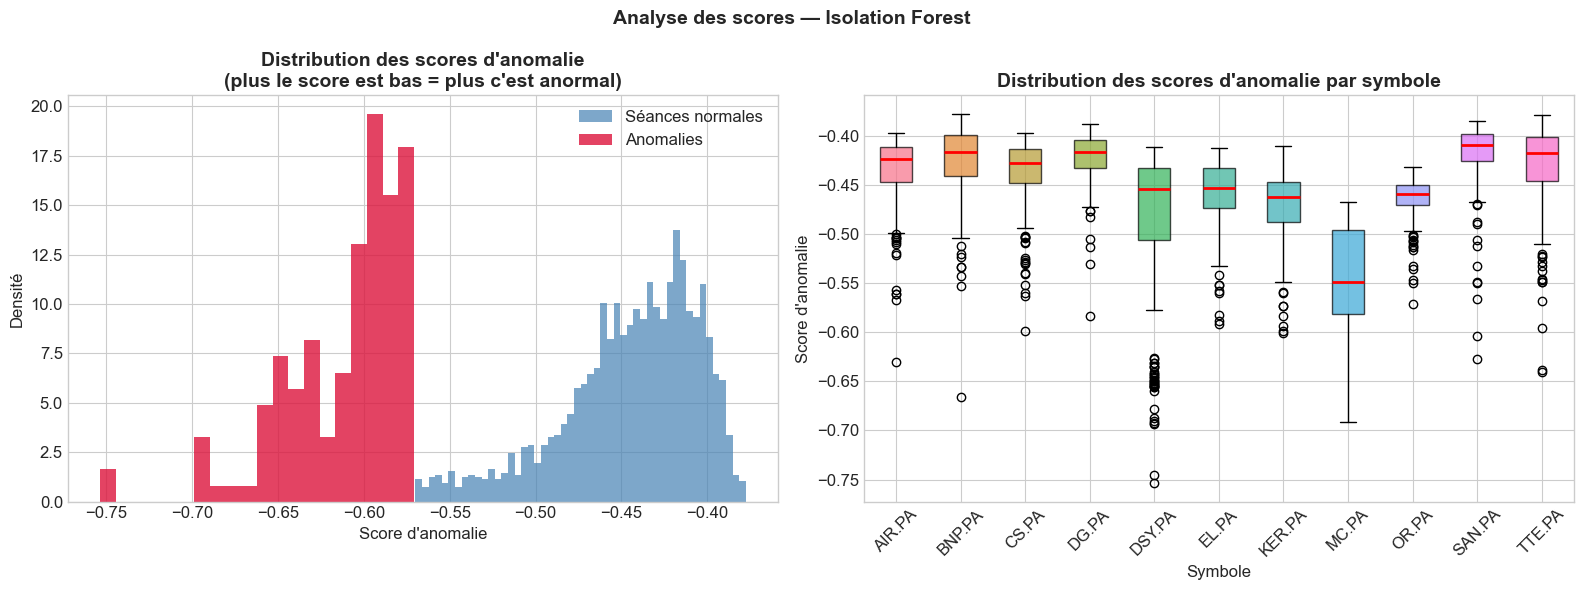

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogramme : scores des séances normales vs anomalies
axes[0].hist(df_anomalies.loc[df_anomalies['est_anomalie']==False, 'score_anomalie'],
             bins=50, alpha=0.7, color='steelblue', label='Séances normales', density=True)
axes[0].hist(df_anomalies.loc[df_anomalies['est_anomalie']==True, 'score_anomalie'],
             bins=20, alpha=0.8, color='crimson', label='Anomalies', density=True)
axes[0].set_title("Distribution des scores d'anomalie\n(plus le score est bas = plus c'est anormal)")
axes[0].set_xlabel("Score d'anomalie")
axes[0].set_ylabel('Densité')
axes[0].legend()

# Boxplot : distribution des scores par symbole
donnees_box = [df_anomalies[df_anomalies['symbole']==sym]['score_anomalie'].values
               for sym in sorted(df_anomalies['symbole'].unique())]
etiquettes = sorted(df_anomalies['symbole'].unique())
bp = axes[1].boxplot(donnees_box, labels=etiquettes, patch_artist=True,
                     medianprops=dict(color='red', linewidth=2))
couleurs_box = sns.color_palette('husl', len(etiquettes))
for patch, c in zip(bp['boxes'], couleurs_box):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)
axes[1].set_title("Distribution des scores d'anomalie par symbole")
axes[1].set_xlabel('Symbole')
axes[1].set_ylabel("Score d'anomalie")
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle("Analyse des scores — Isolation Forest", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('distribution_scores.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Matrice de corrélation des indicateurs

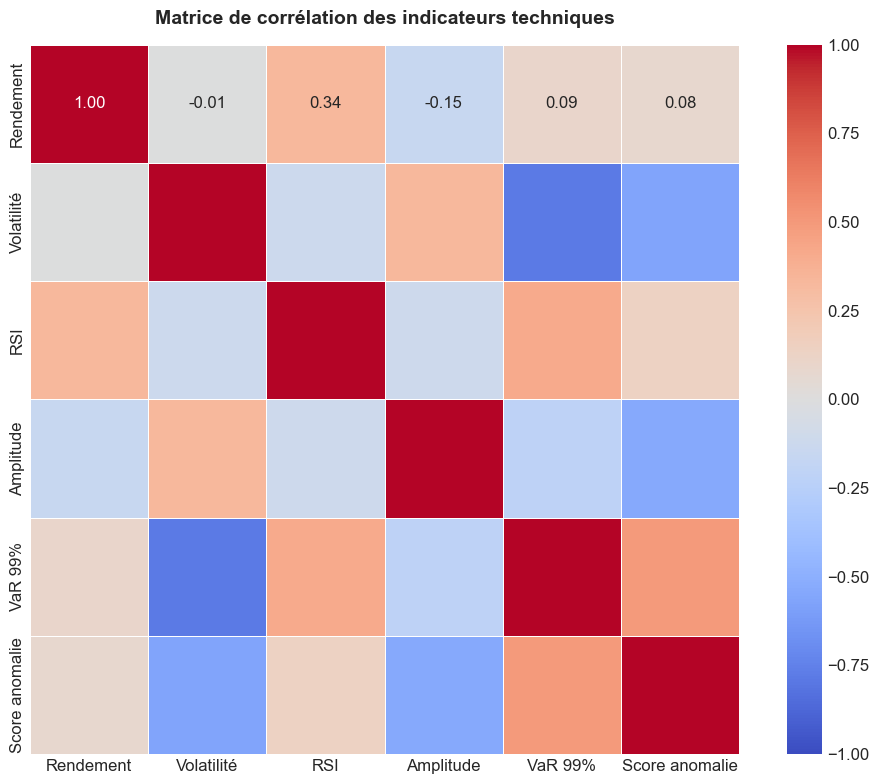

In [9]:
colonnes_corr = ['rendement_log', 'volatilite_annualisee', 'rsi', 'amplitude_journaliere', 'var_historique_99', 'score_anomalie']
noms = {'rendement_log':'Rendement','volatilite_annualisee':'Volatilité','rsi':'RSI',
        'amplitude_journaliere':'Amplitude','var_historique_99':'VaR 99%','score_anomalie':'Score anomalie'}

matrice = df_anomalies[colonnes_corr].corr().rename(index=noms, columns=noms)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(matrice, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title('Matrice de corrélation des indicateurs techniques', pad=15)
plt.tight_layout()
plt.savefig('matrice_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Explorer une autre action

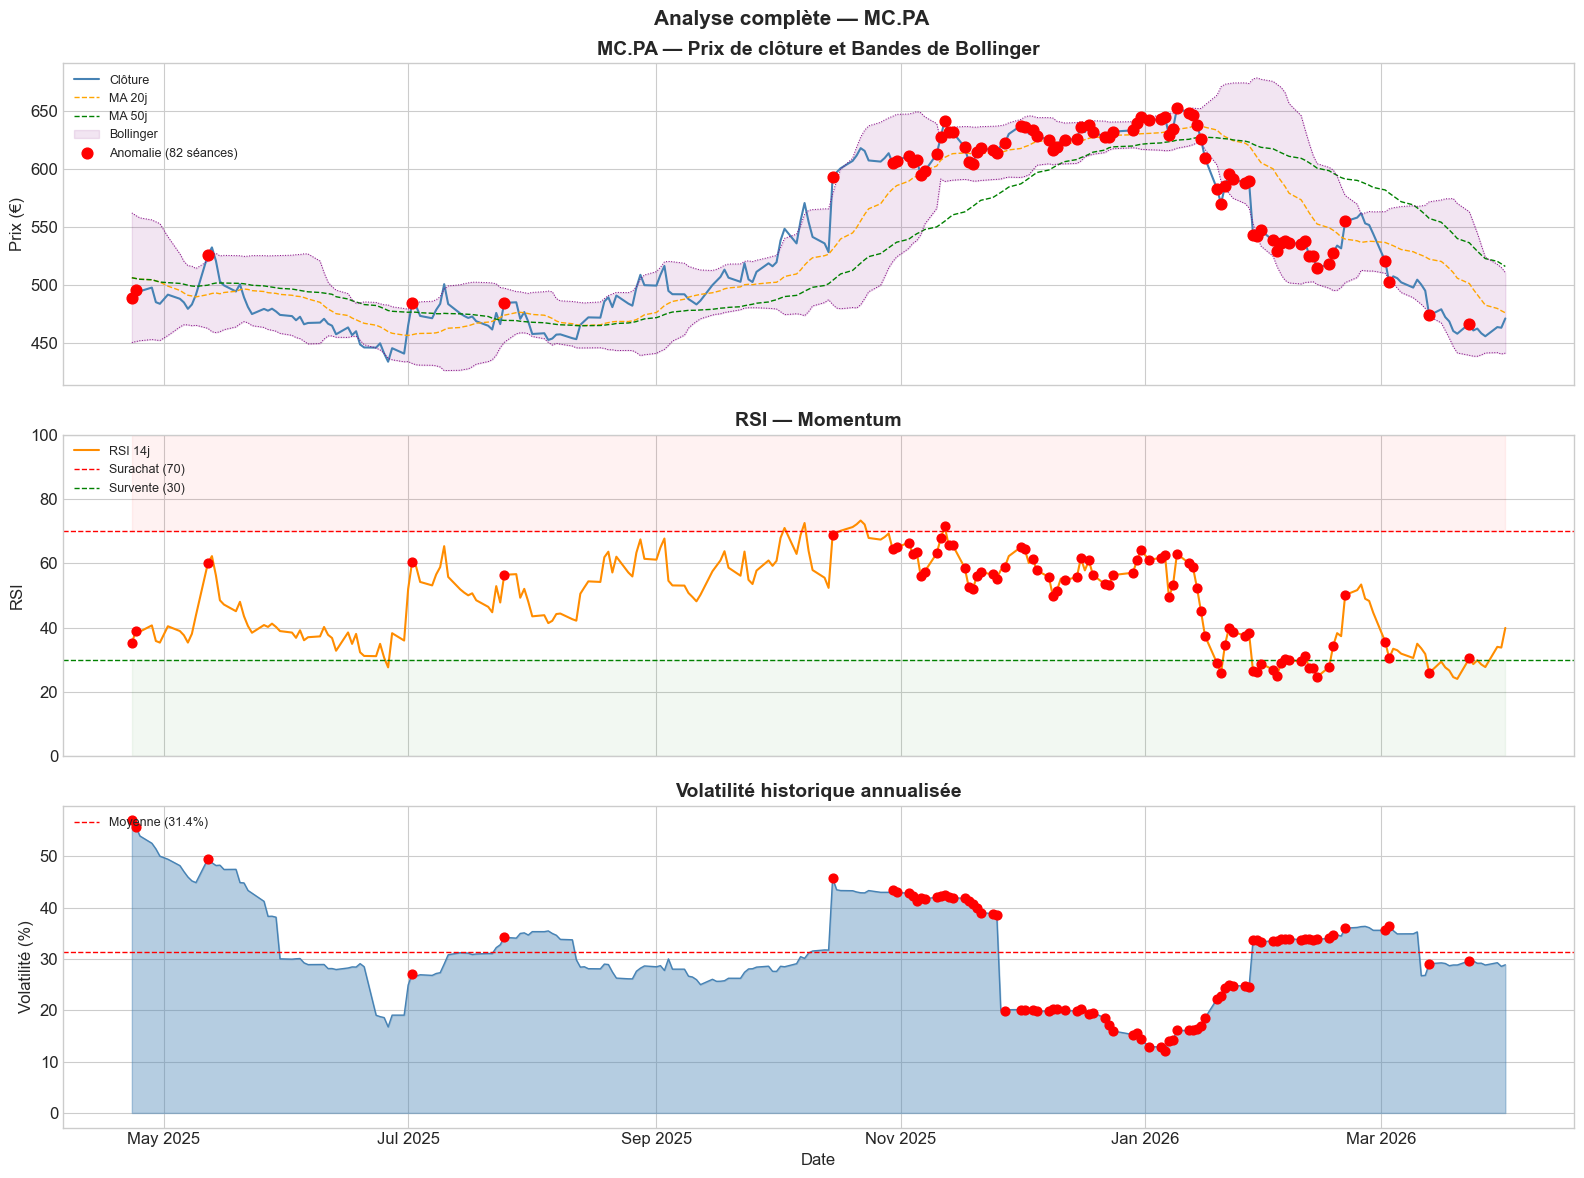

In [ ]:
SYMBOLE = 'MC.PA'  
tracer_prix_anomalies(SYMBOLE, df_anomalies)

# Pour analyser n'importe quelle action du portefeuille, on modifie 'SYMBOLE' ci-dessus par : 'AIR.PA', 'TTE.PA', 'OR.PA', 'STM.PA'...

## 10. Conclusion

Ce notebook illustre les résultats du pipeline ETL de surveillance du risque boursier :

- **Extraction** : cours OHLCV de 12 actions du CAC40 sur 1 an via Yahoo Finance.
- **Transformation** : 7 indicateurs techniques calculés par séance (MA, RSI, Bollinger, Volatilité, VaR, Amplitude).
- **Détection ML** : l'Isolation Forest identifie ~5% de séances anormales sur l'ensemble du portefeuille.
- **Chargement** : données persistées en SQLite et Parquet pour analyses ultérieures.

